In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Kernel Restarts
!pip install --upgrade pip --quiet
!pip install --upgrade transformers --quiet
!pip install --upgrade ipywidgets --quiet

# !pip install -U transformers==4.54.1 --quiet

print("Done installing! Restarting kernel...")
os.kill(os.getpid(), 9)

In [1]:
import transformers
print(f"Installed transformers.__version__={transformers.__version__}")


Installed transformers.__version__=4.55.2


In [6]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import json
import os


from tqdm.notebook import tqdm

In [7]:
BATCH_SIZE = 16
MAX_LENGTH = 128

MODEL_NAME = 'roberta-base'

EPOCHS = 25
PATIENCE = 5 # Early stopping patience
LEARNING_RATE = 2e-4

SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0:'negative',1:'neutral',2:"positive"}

In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# loading the tokenizer and model from HF transformers
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# num_labels = 3 for Postive, Neutral, and Negative sentiment classes
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
all_info = pd.read_csv("/kaggle/input/all_info.csv")
all_info.head()

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
4,negative_005.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative


In [10]:
temp_data = all_info[["OCR","sentiment"]]
temp_data

,OCR,sentiment
0,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,negative
1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,negative
2,NaN,negative
3,NaN,negative
4,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,negative
...,...,...
2870,"66\nJust keep taking\nchances and\nhaving fun,...",positive
2871,66\nNever regret anything\nthat made you smile...,positive
2872,"Click Here\nif you don't\nimagine, nothing\nev...",positive
2873,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,positive


In [11]:
temp_data = temp_data[temp_data['OCR'].notna()]
temp_data['label'] = temp_data['sentiment'].map(SENTIMENTS_TO_LABELS) 
temp_data

/tmp/ipykernel_646/4142500539.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_data['label'] = temp_data['sentiment'].map(SENTIMENTS_TO_LABELS)


,OCR,sentiment,label
0,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,negative,0
1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,negative,0
4,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,negative,0
5,R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BR...,negative,0
6,UKRAINE UNDER ATTACK\nRUSSIAN SHELLING IN OKHT...,negative,0
...,...,...,...
2870,"66\nJust keep taking\nchances and\nhaving fun,...",positive,2
2871,66\nNever regret anything\nthat made you smile...,positive,2
2872,"Click Here\nif you don't\nimagine, nothing\nev...",positive,2
2873,OF COURSE IT'S HARD.\nIT'S SUPPOSED TO BE\nHAR...,positive,2


In [12]:
temp_data.to_csv("temp_data.csv", index=False)

In [13]:
# Split the data
train_val_df, test_df = train_test_split(temp_data, test_size=0.1, stratify=temp_data['label'], random_state=59)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, stratify=train_val_df['label'], random_state=59)

In [14]:
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 2199
Validation set size: 275
Test set size: 275


In [15]:
# Custom Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create DataLoader for each set
train_dataset = SentimentDataset(train_df['OCR'], train_df['label'], tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['OCR'], val_df['label'], tokenizer, MAX_LENGTH)
test_dataset = SentimentDataset(test_df['OCR'], test_df['label'], tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [16]:
# Optimizer and Loss function
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.CrossEntropyLoss()

In [17]:
# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [18]:
import torch
from torch.optim import AdamW
from transformers import get_scheduler
from torch.cuda.amp import autocast, GradScaler

# 1. Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Optimizer with weight decay grouping (recommended for T5)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=5e-5)

# 3. Learning rate scheduler
num_epochs = 25
num_training_steps = len(train_loader) * num_epochs

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 4. Mixed precision scaler (for AMP)
scaler = GradScaler()

# 5. Loss function is already handled inside T5 — just pass labels

/tmp/ipykernel_646/1465637425.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [19]:
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch in train_loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Autocast for mixed precision
        with autocast():
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
        
        # Backpropagation with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        lr_scheduler.step()
        
        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Validation Phase
    model.eval()
    val_loss = 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
    with torch.no_grad():
        for batch in val_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()
            val_loop.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Model Checkpointing and Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'RoBERTa__best_model.pt')
        patience_counter = 0
        print("  ✅ Validation loss improved — saving best model.")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement in validation loss ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered after {epoch} epochs without improvement.")
            break

Epoch 1/25 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

/tmp/ipykernel_646/752944396.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/25 [Validation]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1/25, Train Loss: 0.5346, Validation Loss: 0.3394
  ✅ Validation loss improved — saving best model.


Epoch 2/25 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

...

Epoch 6/25 [Validation]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 6/25, Train Loss: 0.0502, Validation Loss: 0.3339
  ⚠️ No improvement in validation loss (4/5)


Epoch 7/25 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 7/25 [Validation]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 7/25, Train Loss: 0.0382, Validation Loss: 0.3767
  ⚠️ No improvement in validation loss (5/5)
Early stopping triggered after 6 epochs without improvement.


In [20]:
history

{'train_loss': [0.5345528244000414,
  0.2744661642211503,
  0.15094635587698524,
  0.11319067705240425,
  0.0739731647418407,
  0.05023054113490102,
  0.03823520164292279],
 'val_loss': [0.33944513152043027,
  0.23372898581955168,
  0.2950802790001035,
  0.3326799088907946,
  0.3799686816508054,
  0.3339221611386165,
  0.3766613086465643]}

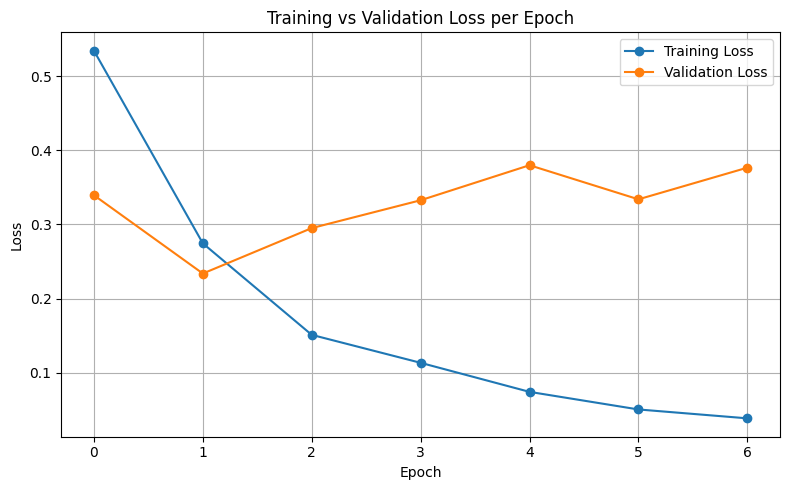

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Training Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("RoBERTa__loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Load the best model weights
model.load_state_dict(torch.load('RoBERTa__best_model.pt'))
model.to(device)

# ==============================================================================
# 3. Evaluation and Visualization
# ==============================================================================

# Post-Training Evaluation on Test Set
def evaluate(data_loader):
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return all_predictions, all_labels

test_predictions, test_labels = evaluate(test_loader)

# Count the sentiment distribution in the test set
unique_labels, counts = np.unique(test_labels, return_counts=True)
sentiment_counts = dict(zip([LABELS_TO_SENTIMENTS[label] for label in unique_labels], counts))

print("\n===== Sentiment Counts in Test Set =====")
print(sentiment_counts)

# Performance Metrics
accuracy = accuracy_score(test_labels, test_predictions)
conf_matrix = confusion_matrix(test_labels, test_predictions)
class_report = classification_report(test_labels, test_predictions, target_names=LABELS_TO_SENTIMENTS.keys(), output_dict=True)

# Create a DataFrame for the confusion matrix with sentiment labels
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f'Actual {s}' for s in LABELS_TO_SENTIMENTS.keys()],
    columns=[f'Predicted {s}' for s in LABELS_TO_SENTIMENTS.keys()]
)

# Print metrics
print("\n===== Evaluation on Test Set =====")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_df)
print("\nClassification Report:")
print(class_report)

# Save metrics to JSON
metrics_dict = {
    'accuracy': accuracy,
    'confusion_matrix_instructions': "Row_i represents actual_class_i \n Column_j represents predicted_class_j",
    'confusion_matrix': conf_matrix_df.values.tolist(),
    'classification_report': class_report
}

with open('RoBERTa__test_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("\nEvaluation metrics saved to 'RoBERTa__test_metrics.json'.")


===== Sentiment Counts in Test Set =====
{'negative': np.int64(86), 'neutral': np.int64(90), 'positive': np.int64(99)}

===== Evaluation on Test Set =====
Accuracy: 0.8982

Confusion Matrix:
          Predicted 0  Predicted 1  Predicted 2
Actual 0           66           12            8
Actual 1            1           87            2
Actual 2            0            5           94

Classification Report:
{0: {'precision': 0.9850746268656716, 'recall': 0.7674418604651163, 'f1-score': 0.8627450980392157, 'support': 86.0}, 1: {'precision': 0.8365384615384616, 'recall': 0.9666666666666667, 'f1-score': 0.8969072164948454, 'support': 90.0}, 2: {'precision': 0.9038461538461539, 'recall': 0.9494949494949495, 'f1-score': 0.9261083743842364, 'support': 99.0}, 'accuracy': 0.8981818181818182, 'macro avg': {'precision': 0.9084864140834289, 'recall': 0.8945344922089108, 'f1-score': 0.8952535629727659, 'support': 275.0}, 'weighted avg': {'precision': 0.9072205406533765, 'recall': 0.8981818181818182, 

In [ ]:
# Inference Function
def predict_sentiment(text):
    model.eval()
    # Pre-process and tokenize the text
    encoding = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Pass processed input to the model
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()
        
    # Convert output to a sentiment prediction
    inverse_label_map = {v: k for k, v in label_map.items()}
    return inverse_label_map[prediction], probabilities.cpu().numpy().flatten()

# Example usage of the inference function
example_text = "This is a great product! I'm so happy with it."
sentiment, probabilities = predict_sentiment(example_text)
print("\n===== Inference Example =====")
print(f"Text: '{example_text}'")
print(f"Predicted Sentiment: {sentiment}")
print(f"Probabilities: Negative={probabilities[0]:.4f}, Neutral={probabilities[1]:.4f}, Positive={probabilities[2]:.4f}")